# Regression Using scikit-learn and NumPy

In [20]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

In [21]:
df = pd.read_csv("Student_Performance.csv")
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


In [22]:
df['Extracurricular Activities'] = df['Extracurricular Activities'].map({'Yes': 1, 'No': 0})
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,1,9,1,91.0
1,4,82,0,4,2,65.0
2,8,51,1,7,2,45.0
3,5,52,1,5,2,36.0
4,7,75,0,8,5,66.0


In [23]:
X = df.drop('Performance Index', axis=1).values
y = df['Performance Index'].values

print(f"Sample X is {X[0:5]} and Sample Y is {y[0:5]}")

Sample X is [[ 7 99  1  9  1]
 [ 4 82  0  4  2]
 [ 8 51  1  7  2]
 [ 5 52  1  5  2]
 [ 7 75  0  8  5]] and Sample Y is [91. 65. 45. 36. 66.]


In [24]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## scikit-learn

In [25]:
#Using scikit-learn for linear regression without feature scaling

sk_model = LinearRegression()
sk_model.fit(X_train, y_train)

sk_preds = sk_model.predict(X_test)

sk_mse = mean_squared_error(y_test, sk_preds)
sk_r2 = r2_score(y_test, sk_preds)

print("Scikit-learn Results")
print("MSE:", sk_mse)
print("R2:", sk_r2)
print("Coefficients:", sk_model.coef_)
print("Intercept:", sk_model.intercept_)

LinearRegression()

Scikit-learn Results
MSE: 4.08262839852186
R2: 0.9889832909573145
Coefficients: [2.85248393 1.0169882  0.60861668 0.47694148 0.19183144]
Intercept: -33.921946215556254


In [26]:
# Feature Scaling using scikit-learn
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train) 
X_test_scaled = scaler.transform(X_test)         

model = LinearRegression()
model.fit(X_train_scaled, y_train)

preds = model.predict(X_test_scaled)

mse = mean_squared_error(y_test, preds)
r2 = r2_score(y_test, preds)

print("Scaled Linear Regression Results")
print("MSE:", mse)
print("R2:", r2)
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

LinearRegression()

Scaled Linear Regression Results
MSE: 4.082628398521858
R2: 0.9889832909573145
Coefficients: [ 7.40134079 17.63727127  0.30429076  0.81003107  0.54884171]
Intercept: 55.31150000000001


## NumPy (Using Gradient Descent)

In [27]:
X_train_b = np.c_[np.ones(X_train.shape[0]), X_train]
X_test_b = np.c_[np.ones(X_test.shape[0]), X_test]


def gradient_descent(X, y, lr=0.01, epochs=3000):
    m, n = X.shape
    theta = np.zeros(n)
    
    for _ in range(epochs):
        gradients = (2/m) * X.T.dot(X.dot(theta) - y)
        theta -= lr * gradients
        
    return theta


#Manual feature scaling using NumPy
mean = X_train.mean(axis=0)
std = X_train.std(axis=0)

#To prevent division by zero
std[std == 0] = 1

X_train_scaled = (X_train - mean) / std
X_test_scaled = (X_test - mean) / std

X_train_b = np.c_[np.ones(X_train_scaled.shape[0]), X_train_scaled]
X_test_b = np.c_[np.ones(X_test_scaled.shape[0]), X_test_scaled]

theta = gradient_descent(X_train_b, y_train, lr=0.01, epochs=2000)

In [28]:
gd_preds = X_test_b.dot(theta)

gd_mse = mean_squared_error(y_test, gd_preds)
gd_r2 = r2_score(y_test, gd_preds)

print("\nGradient Descent Results")
print("MSE:", gd_mse)
print("R2:", gd_r2)
print("Coefficients:", theta[1:])
print("Intercept:", theta[0])


Gradient Descent Results
MSE: 4.082628398521848
R2: 0.9889832909573145
Coefficients: [ 7.40134079 17.63727127  0.30429076  0.81003107  0.54884171]
Intercept: 55.31149999999983


In [29]:
# Plotting cost function vs iteration number 

def gradient_descent_with_cost(X, y, lr=0.01, epochs=200):
    m, n = X.shape
    theta = np.zeros(n)
    cost_history = []

    for _ in range(epochs):
        predictions = X.dot(theta)
        errors = predictions - y
        
        cost = (1/m) * np.sum(errors ** 2)
        cost_history.append(cost)

        gradients = (2/m) * X.T.dot(errors)
        theta -= lr * gradients

    return theta, cost_history


theta, cost_history = gradient_descent_with_cost(X_train_b, y_train)

Text(0.5, 0, 'Iterations')

Text(0, 0.5, 'Cost (MSE)')

Text(0.5, 1.0, 'Gradient Descent Convergence')

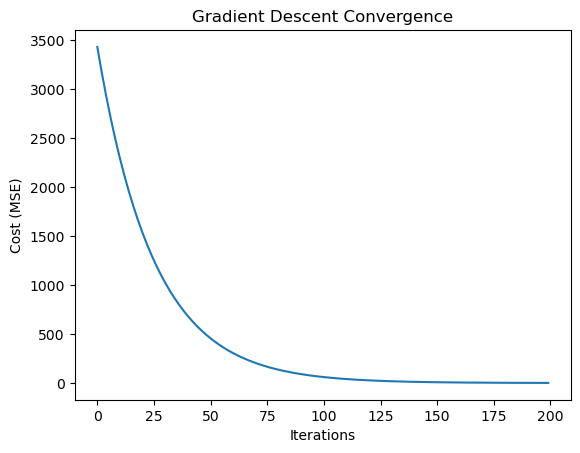

In [30]:
import matplotlib.pyplot as plt

plt.plot(cost_history)
plt.xlabel("Iterations")
plt.ylabel("Cost (MSE)")
plt.title("Gradient Descent Convergence")
plt.show()

## Comparison of scikit-learn and NumPy for linear regression

Text(0.5, 0, 'Scikit-learn Predictions')

Text(0, 0.5, 'Gradient Descent Predictions')

Text(0.5, 1.0, 'Prediction Comparison')

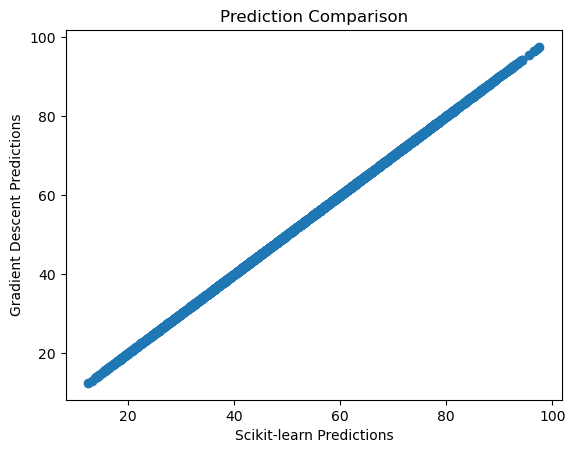

In [31]:
plt.scatter(sk_preds, gd_preds)
plt.xlabel("Scikit-learn Predictions")
plt.ylabel("Gradient Descent Predictions")
plt.title("Prediction Comparison")
plt.show()

<Figure size 640x480 with 0 Axes>

(array([  1.,  13.,  22.,   0.,  81.,  87., 148.,   0.,  82., 134.,  16.,
        119.,  72., 134.,  81.,  46., 107.,  79., 150.,  55., 133.,  80.,
         41.,  92.,  73.,  50.,  51.,  33.,  16.,   4.]),
 array([-3.26849658e-13, -3.16665213e-13, -3.06480767e-13, -2.96296321e-13,
        -2.86111875e-13, -2.75927429e-13, -2.65742983e-13, -2.55558537e-13,
        -2.45374091e-13, -2.35189646e-13, -2.25005200e-13, -2.14820754e-13,
        -2.04636308e-13, -1.94451862e-13, -1.84267416e-13, -1.74082970e-13,
        -1.63898524e-13, -1.53714079e-13, -1.43529633e-13, -1.33345187e-13,
        -1.23160741e-13, -1.12976295e-13, -1.02791849e-13, -9.26074032e-14,
        -8.24229573e-14, -7.22385115e-14, -6.20540656e-14, -5.18696197e-14,
        -4.16851738e-14, -3.15007280e-14, -2.13162821e-14]),
 [<matplotlib.patches.Polygon at 0x211bad98690>])

Text(0.5, 0, 'Residual Difference (Sklearn - GD)')

Text(0, 0.5, 'Frequency')

Text(0.5, 1.0, 'Residual Difference Distribution')

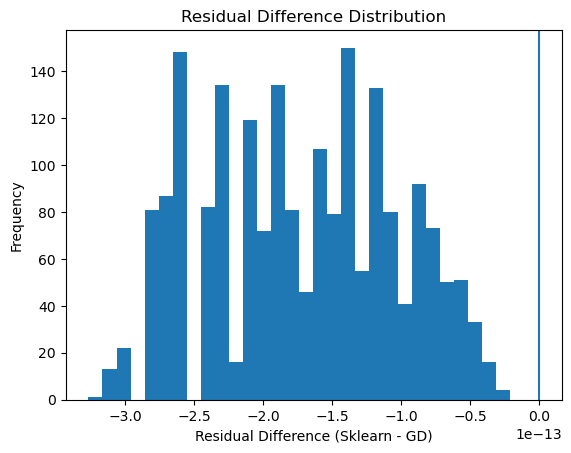

In [32]:
sk_residuals = y_test - sk_preds
gd_residuals = y_test - gd_preds

diff = sk_residuals - gd_residuals

plt.figure()
plt.hist(diff, bins=30, histtype='stepfilled')

plt.axvline(0)
plt.xlabel("Residual Difference (Sklearn - GD)")
plt.ylabel("Frequency")
plt.title("Residual Difference Distribution")
plt.show()

In [33]:
import time

start = time.time()
sk_model.fit(X_train_scaled, y_train)
print("Scikit-learn Time:", time.time() - start)

start = time.time()
theta, _ = gradient_descent_with_cost(X_train_b, y_train)
print("Gradient Descent Time:", time.time() - start)


LinearRegression()

Scikit-learn Time: 0.00651097297668457
Gradient Descent Time: 0.0852360725402832
